In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [2]:
df =pd.read_csv('Pharma_Industry.csv')
df

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1
...,...,...,...,...,...,...
495,-1.553759,0.506938,0.817890,-0.661245,-1.345393,0
496,0.551476,1.714321,0.340589,1.712558,-0.496315,1
497,-1.072743,-0.221137,0.239247,1.112924,-0.285838,1
498,1.661259,0.245759,-0.457096,0.633355,0.657413,0


In [3]:
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [4]:
df.dtypes

Drug Dosage (mg)                  float64
Systolic Blood Pressure (mmHg)    float64
Heart Rate (BPM)                  float64
Liver Toxicity Index (U/L)        float64
Blood Glucose Level (mg/dL)       float64
Drug Response                       int64
dtype: object

In [15]:
df.columns

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

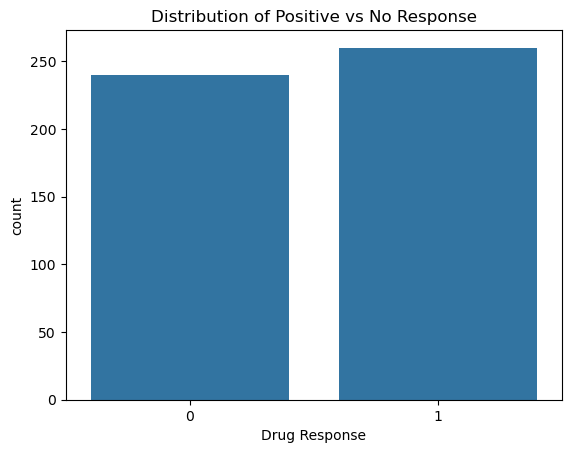

In [5]:
# Check class distributio
sns.countplot(x='Drug Response', data=df)
plt.title('Distribution of Positive vs No Response')
plt.show()

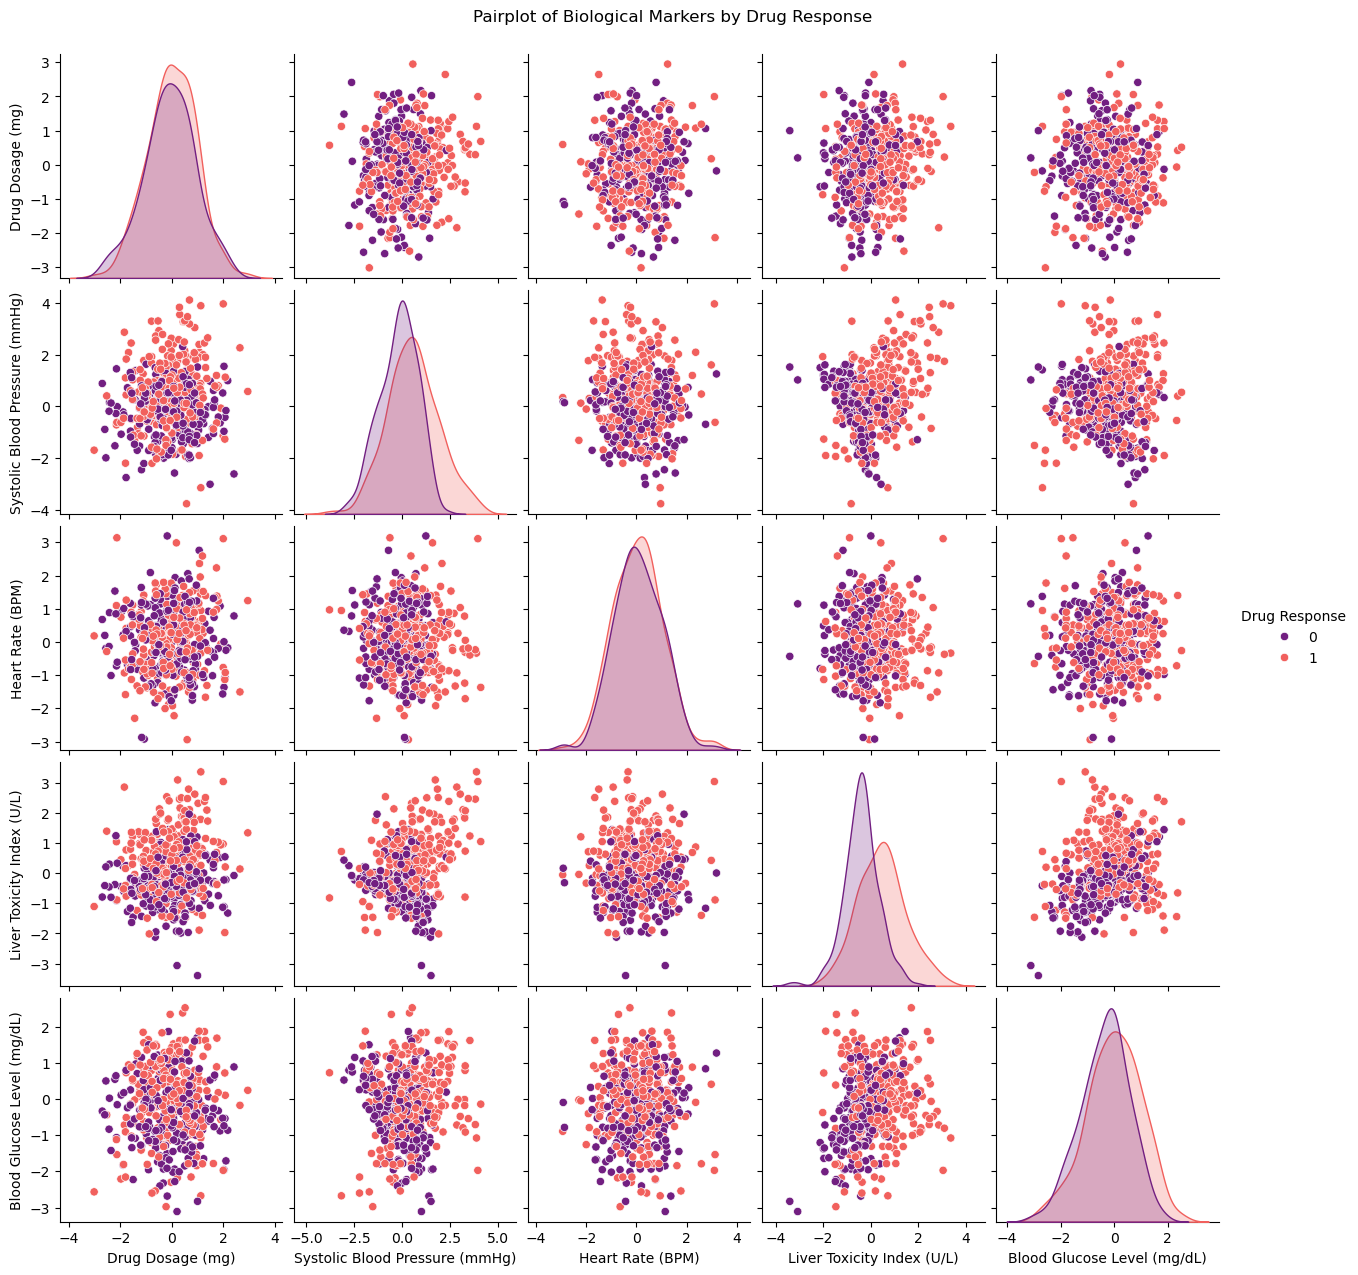

In [21]:
sns.pairplot(df, hue='Drug Response', palette='magma', diag_kind='kde')

plt.suptitle('Pairplot of Biological Markers by Drug Response', y=1.02)
plt.show()

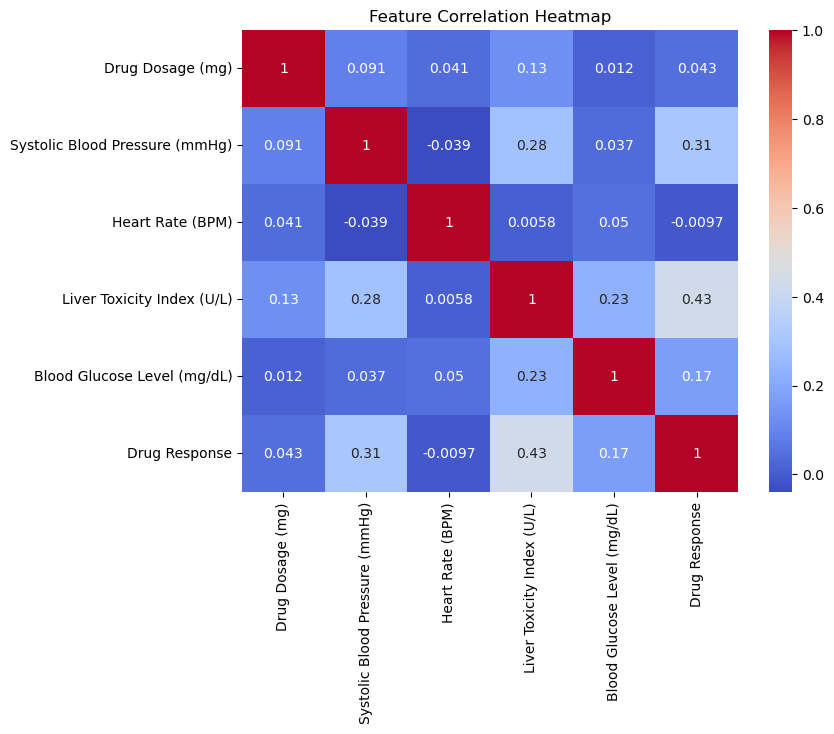

In [6]:
#Feature correlation
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [7]:
#Task 2: Data Preprocessing
X = df.drop('Drug Response', axis=1)
y = df['Drug Response']

In [8]:
# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

SVM Performance Metrics:
Accuracy: 0.78
              precision    recall  f1-score   support

           0       0.72      0.82      0.77        44
           1       0.84      0.75      0.79        56

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100



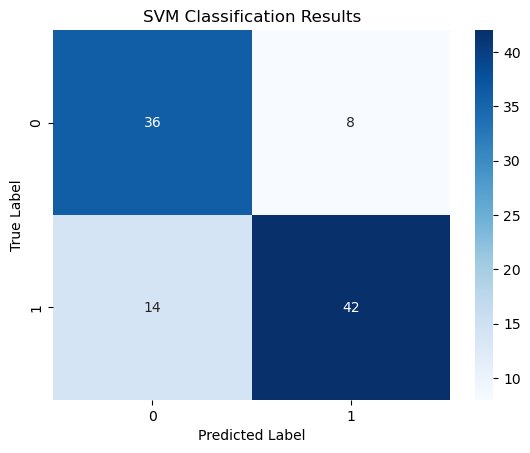

In [10]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Implement basic SVM classifier [cite: 15]
svm_model = SVC(kernel='linear') # Starting with a linear kernel [cite: 23]
svm_model.fit(X_train, y_train)

# Evaluate model performance on testing data [cite: 17]
y_pred = svm_model.predict(X_test)

print("SVM Performance Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

# Visualize classification results (Confusion Matrix) [cite: 19]
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM Classification Results')
plt.show()

In [11]:
# Experiment with different kernels to optimize performance 
kernels = ['linear', 'poly', 'rbf']

for k in kernels:
    model = SVC(kernel=k, C=1.0) # C is the regularization parameter [cite: 21]
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"SVM Kernel: {k} | Accuracy: {score:.4f}")

# Discussion of results 
# Based on the EDA and visualization, we analyze which kernel handles 
# the non-linear biological markers most effectively.

SVM Kernel: linear | Accuracy: 0.7800
SVM Kernel: poly | Accuracy: 0.6900
SVM Kernel: rbf | Accuracy: 0.8200


### Analysis Summary 
##### Strengths: SVM is effective in high-dimensional spaces, such as datasets with multiple biomarkers (BP, Glucose, Toxicity).
##### Weaknesses: It can be sensitive to noise if biological data overlaps significantly between "No Response" and "Positive Response".
##### Real-world Implications: Predictive models like this allow for Personalized Medicine, ensuring patients receive the right dose and reducing the risks of liver toxicity.